#### 1. Binary Tree Helper Class Concept

We separate the responsibilities 

Node Class
    Represents a single node in the tree

BinaryTree Class 
    Provides operations on the tree 

In [ ]:
class Node:
    def __init__(self, value):
        self.value = value 
        self.left = None
        self.right = None 

class BinaryTree:
    def __init__(self):
        self.root = None 




### Binary Tree Implementation (using classes) 


In [2]:
class Node: 
    def __init__(self, key):
        self.key = key 
        self.left = None 
        self.right = None 

class BinaryTree:
    def __init__(self):
        self.root = None 

    # insert using recursive approach 
    def insert(self, key):
        if not self.root:
            self.root = Node(key)
            return 
        self._insert(self.root, key)

    def _insert(self, node, key):
        if not node.left:
            node.left = Node(key)
        elif not node.right:
            node.right = Node(key)
        else:
            # Insert recursively into left subtree (basic strategy)
            self._insert(node.left, key)

    # tree traversals
    def inorder (self, node):
        if node:
            self.inorder(node.left)
            print(node.key, end=" ")
            self.inorder(node.right)

    def preorder(self, node):
        if node: 
            print (node.key, end=" ")
            self.preorder(node.left)
            self.preorder(node.right)

    def postorder(self, node):
        if node:
            self.postorder(node.left)
            self.postorder(node.right)
            print(node.key, end=" ")

    # delete by replacing with deepest node
    def delete(self, key):
        if not self.root:
            return 
        self.root = self._delete(self.root, key)

    def _delete(self, node, key):
        if not node:
            return None 
        if node.key == key:
            # repplace with right child if existis, else left 
            if node.right:
                return node.right 
            else:
                return node.left
            
        node.left = self._delete(node.left, key)
        node.right = self._delete(node.right, key)
        return node
    

bt = BinaryTree()
bt.insert(10)
bt.insert(20)
bt.insert(30)
bt.insert(40)
bt.insert(50)

print("Inorder:", end=" ")
bt.inorder(bt.root)
print("\nPreorder:", end=" ")
bt.preorder(bt.root)
print("\nPostorder:", end=" ")
bt.postorder(bt.root)

bt.delete(20)
print("\nAfter deletion (Inorder):", end=" ")
bt.inorder(bt.root)

Inorder: 40 20 50 10 30 
Preorder: 10 20 40 50 30 
Postorder: 40 50 20 30 10 
After deletion (Inorder): 50 10 30 

### Binary Tree Implementation (using deque)

In [ ]:
from collections import deque 

class Node:
    def __init__(self, key):
        self.key = key 
        self.left = None 
        self.right = None 

class BinaryTreeDeque:
    def __init__(self):
        self.root = None 

    def insert(self, key):
        # create a new node 
        new_node = Node(key)
        # if the tree is emptym, assign the new node as root 
        if not self.root:
            self.root = new_node 
            return 
        # initialize the deque with root node
        # this sets up for level-order-traversal - visiting nodes fromtop to bottom, left to right
        dq = deque([self.root])
        while dq:
            # pops the fron node of the queue to inspect it
            temp = dq.popleft()
            # if left child check, insert if no left child 
            if not temp.left:
                temp.left = new_node
                break             
            else:
                # add to the queue for later inspection
                dq.append(temp.left)
            # check for the right child, insert if not found
            if not temp.right:
                temp.right = new_node
                break 
            else:
                # add to the queue for further inspection
                dq.append(temp.right)
        
    def inorder(self, node):
        if node:
            self.inorder(node.left)
            print (node.key, end=' ')
            self.inorder(node.right)
    
    def preorder(self, node):
        if node:
            print  (node.key, end=' ')
            self.preorder(node.left)
            self.preorder(node.right)

    def postorder(self, node):
        if node:
            self.postorder(node.left)
            self.postorder(node.right)
            print(node.key, end=' ')

    # deleting a node 
    def delete(self, key):
        if not self.root:
            return 
        dq = deque([self.root])
        node_to_delete = None 
        last_node = None 
        parent_of_last = None 

        while dq:
            last_node = dq.popleft() 
            if last_node.key == key:
                node_to_delete = last_node
            if last_node.left:
                parent_of_last = last_node 
                dq.append(last_node.left)
            if last_node.right:
                parent_of_last = last_node
                dq.append(last_node.right)

        if node_to_delete:
            node_to_delete.key = last_node.key 
            #removbe deepese node

            if parent_of_last.right == last_node:
                parent_of_last.right = None 
            else:
                parent_of_last.left = None 


# Example usage
btq = BinaryTreeDeque()
btq.insert(10)
btq.insert(20)
btq.insert(30)
btq.insert(40)

print("Inorder:", end=" ")
btq.inorder(btq.root)
print("\nPreorder:", end=" ")
btq.preorder(btq.root)
print("\nPostorder:", end=" ")
btq.postorder(btq.root)

btq.delete(20)
print("\nAfter deletion (Inorder):", end=" ")
btq.inorder(btq.root)

""" 
🔑 Key Differences
- Without deque: recursion is used for insertion/deletion, which is less efficient for level-order operations.
- With deque: insertion and deletion are done in O(n) but in a clean, iterative way using breadth-first traversal.
Would you like me to also add a level-order traversal (BFS) method to both versions so you can see the practical difference between recursive vs deque-based approaches?

"""

Inorder: 40 20 10 30 
Preorder: 10 20 40 30 
Postorder: 40 20 30 10 
After deletion (Inorder): 40 10 30 

' \n🔑 Key Differences\n- Without deque: recursion is used for insertion/deletion, which is less efficient for level-order operations.\n- With deque: insertion and deletion are done in O(n) but in a clean, iterative way using breadth-first traversal.\nWould you like me to also add a level-order traversal (BFS) method to both versions so you can see the practical difference between recursive vs deque-based approaches?\n\n'

### level Order Traversal (Breadth First Search of a Binary Tree) 

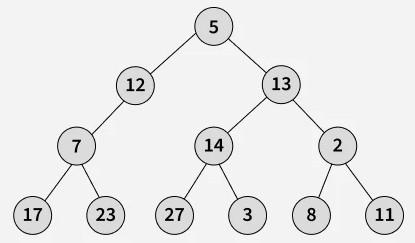

Output: [[5], [12, 13], [7, 14, 2], [17, 23, 27, 3, 8, 11]]

Explanation:  Start with the root - [5]

    Level 1: [12, 13]

    Level 2: [7, 14, 2]

    Level 3: [17, 23, 27, 3, 8, 11]

### Approach - Using Recursion - O(n) time and O(n) space 

The idea is to traversse the treee recursively, starting from the root at level 0. 

When a node is visitedm its value is added to the result array at the index corresponding to its level, and then its children are recursively processed in the same way. 

This effectively performs a level-order traversal using recursion. 

In [ ]:
#        
class Node: 
    def __init__(self, data):
        self.data = data 
        self.left = None 
        self.right = None 
    
def levelOrderRec(root, level, res):
    # Base Case 
    if root is None:
        return 
    
    # Add a new level to the result if needed
    if len(res) <= level:
        res.append([])

    # Add current node's data to its corresponding level
    res[level].append(root.data)

    # recursive call for left and right children 
    levelOrderRec(root.left, level+1, res)
    levelOrderRec(root.right, level+1, res)

def levelOrder(root):
    res = []
    levelOrderRec(root, 0, res)
    return res

if __name__ == "__main__":
    root = Node(5)
    root.left = Node(12)
    root.right = Node(13)

    root.left.left = Node(7)
    root.left.right = Node(14)

    root.right.right = Node(2)

    root.left.left.left = Node(17)
    root.left.left.right = Node(23)

    root.left.right.left = Node(27)
    root.left.right.right = Node(3)

    root.right.right.left = Node(8)
    root.right.right.right = Node(11)

    res = levelOrder(root)

    for level in res:
        print(' '.join(map(str, level)))


# Input tree 
    #      5
    #     / \
    #   12   13
    #   /  \    \
    #  7    14    2
    # /  \  /  \  / \
    #17  23 27 3 8  11        


5
12 13
7 14 2
17 23 27 3 8 11


### Expected Approach - Using Queue (Iterative) - O(n) time and O(n) space 

The idea is to use a queue to traverse the tree level by level. Start by adding the root to the queue. Then, repeatedly remove a node from the queue, store its value in the result, and add its left and right children to the queue. Continue this process until the queue is empty.

In [5]:
class Node:
    def __init__ (self, data):
        self.data = data 
        self.left = None 
        self.right = None

def levelOrder(root):
    if root is None:
        return 

    q = []
    res = []

    q.append(root)
    curr_level = 0 

    while q:
        lenq = len(q)
        res.append([])

        for _ in range(lenq):
            node = q.pop(0) 
            res[curr_level].append(node.data)

            if node.left is not None:
                q.append(node.left)

            if node.right is not None:
                q.append(node.right)

        curr_level += 1
    return res 


if __name__ == '__main__':
    #      5
    #     / \
    #   12   13
    #   /  \    \
    #  7    14   2
    # /  \ /  \  / \
    #17 23 2  3 8  11

    root = Node(5)
    root.left = Node(12)
    root.right = Node(13)

    root.left.left = Node(7)
    root.left.right = Node(14)

    root.right.right = Node(2)

    root.left.left.left = Node(17)
    root.left.left.right = Node(23)

    root.left.right.left = Node(27)
    root.left.right.right = Node(3)

    root.right.right.left = Node(8)
    root.right.right.right = Node(11)

    # Perform level order traversal and get the result
    res = levelOrder(root)
    for level in res:
        for val in level:
            print(val, end=' ')
        print()


5 
12 13 
7 14 2 
17 23 27 3 8 11 


### Deletion in a Binary Tree

